In [1]:
import numpy as np
import os
import globals as gl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from Plot import make_yref, set_spines_and_ticks_width

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


/tmp/ipykernel_82940/3396233123.py:21: RuntimeWarning: Mean of empty slice.
  force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
/home/ROBARTS/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/ROBARTS/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/ROBARTS/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/ROBARTS/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/sit

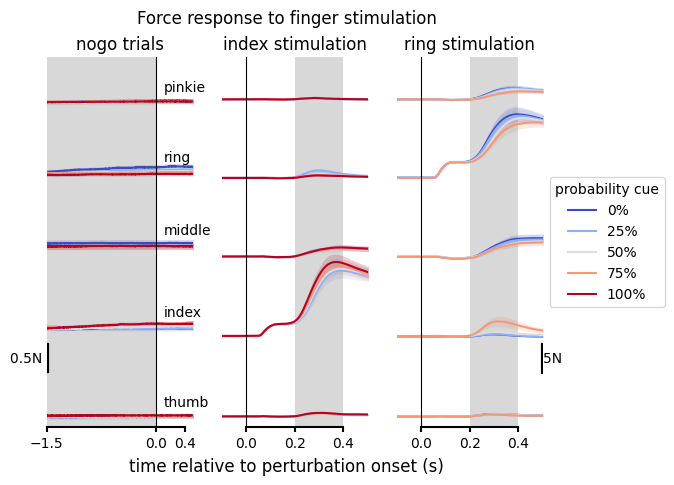

In [4]:
experiment = 'smp2'

npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir,'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

fig, axs = plt.subplots(ncols=3, )

vsep_go = 15
vsep_nogo = 1.5

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        if stimF != 'nogo':
            axs[sf].set_title(f'{stimF} stimulation')
        else:
            axs[sf].set_title('nogo trials')
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            if (sf==2) & (f==0):
                axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[c],  label=cue)
            else:
                axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[c])
            axs[sf].fill_between(tAx, force_avg + f * vsep_go - force_err, force_avg + f * vsep_go + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[0].plot(tAx, force_avg + f * vsep_nogo, color=list(gl.colour_mapping.values())[c])
            axs[0].fill_between(tAx, force_avg + f * vsep_nogo - force_err, force_avg + f * vsep_nogo + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for f, finger in enumerate(descr.finger.unique()):
    force_avg = force[(descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
    force_err = force[(descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
    axs[0].text(.1, force_avg.mean() + f * vsep_nogo + force_err.mean() + .1, finger, va='bottom', ha='left')

for ax in axs:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])

axs[0].axvspan(-1.5, 0, color='grey', alpha=.3, lw=0)
axs[1].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
axs[2].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
axs[0].set_xlim([-1.5, .5])
axs[1].set_xlim([-.1, .5])
axs[2].set_xlim([-.1, .5])
axs[0].set_ylim([-.21, 6.90])
axs[1].set_ylim([-2, 68])
axs[2].set_ylim([-2, 68])

axs[0].set_xticks([-1.5, 0, .4])
axs[1].set_xticks([0, .2, .4])
axs[2].set_xticks([0, .2, .4])

make_yref(axs[2], reference_length=5, pos='right')
make_yref(axs[0], reference_length=.5, pos='left')

axs[0].spines[['bottom',]].set_bounds(-1.5, .4)
axs[1].spines[['bottom',]].set_bounds(0, .4)
axs[2].spines[['bottom',]].set_bounds(0, .4)

axs[2].legend(loc='center left', bbox_to_anchor=(1, 0.5), title='probability cue')

for ax in axs:
    set_spines_and_ticks_width(ax, spine_width=1.5,spine_sides=('bottom',), tick_width=1.5,axes='x',which='both')

fig.suptitle('Force response to finger stimulation')
fig.supxlabel('time relative to perturbation onset (s)')

plt.show()

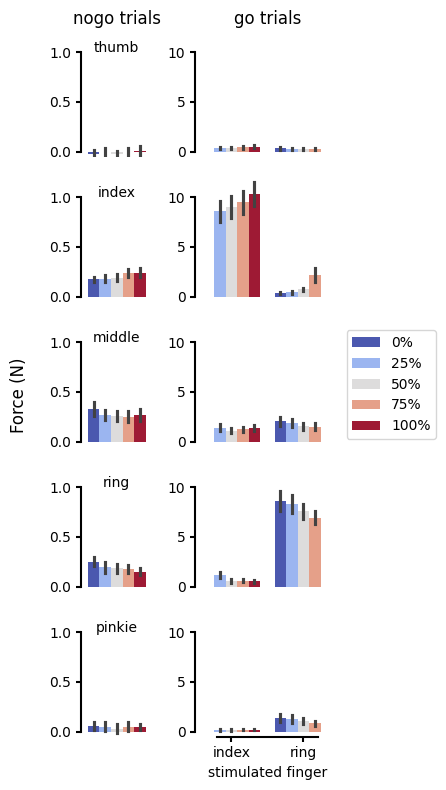

In [28]:
snS = [102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(5, 2, figsize=(4.5, 8), gridspec_kw={'width_ratios': [1, 2]})

for f, finger in enumerate(gl.channels['mov']):
    if f==2:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=True, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')
    else:
        sns.barplot(x='stimFinger', y=finger + '1', ax=axs[f, 1], hue='cue', data=df[df['GoNogo']=='go'], legend=False, order=['index', 'ring'],hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 1].set_ylim([-.5, 12])
    axs[f, 1].set_xlabel('')
    axs[f, 1].set_ylabel('')
    # axs[f, 1].set_title(finger)
    axs[f, 1].spines[['left',]].set_bounds(0, 10)

    if f<4:
        axs[f, 1].set_xticks([])
        axs[f, 1].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 1].set_title(f'go trials')

for f, finger in enumerate(gl.channels['mov']):
    sns.barplot(x='stimFinger', y=finger + '0', ax=axs[f, 0], hue='cue', data=df[df['GoNogo']=='nogo'], legend=False, hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5], errorbar='se')

    axs[f, 0].set_ylim([-.05, 1.2])
    axs[f, 0].set_xlabel('')
    axs[f, 0].set_ylabel('')
    axs[f, 0].text(0, 1, finger, ha='center')
    axs[f, 0].spines[['left',]].set_bounds(0, 1)

    axs[f, 0].set_xticks([])
    axs[f, 0].spines[['bottom','right','top']].set_visible(False)

    if f==0:
        axs[f, 0].set_title(f'nogo trials')

axs[-1, -1].set_xlabel('stimulated finger')
axs[-1, -1].spines[['right','top']].set_visible(False)
axs[-1, -1].spines[['bottom',]].set_bounds(-.2, 1.2)
axs[2, 1].legend(loc='center left', bbox_to_anchor=(1, 0.5), )

for row in range(5):
    for col in range(2):
        set_spines_and_ticks_width(axs[row, col], spine_width=1.5,spine_sides=('bottom', 'left'), tick_width=1.5,axes=('x', 'y'),which='both')

fig.supylabel('Force (N)')
fig.tight_layout()